In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
file_name = "survey-data.csv.csv"
df = pd.read_csv(file_name)
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
2,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
3,11,"I used to be a developer by profession, but no...",35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Written Tutorial...,...,25.0,10.0,0.0,15.0,0.0,0.0,Appropriate in length,Easy,NaN,8.0
4,12,I am a developer by profession,45-54 years old,"Employed, full-time",In-person,Apples,Hobby;School or academic work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Books / Physical media;School (i.e., Universit...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN


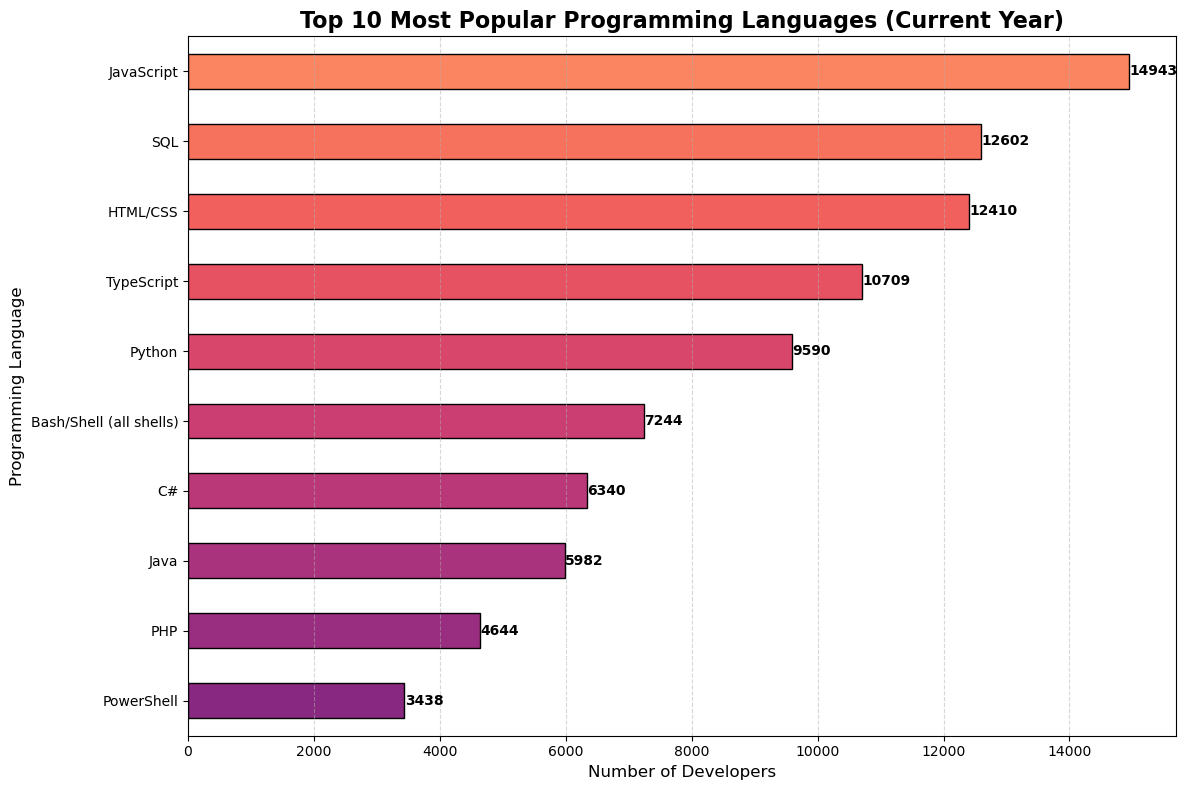

In [7]:

# 1. تنظيف البيانات وتجهيز عمود اللغات الحالية
df_current = df[['LanguageHaveWorkedWith']].dropna().copy()

# 2. تفكيك اللغات (لأن الصف الواحد يحتوي على عدة لغات)
df_current['Language'] = df_current['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df_current.explode('Language')

# 3. حساب التكرار لأعلى 10 لغات استخداماً
top_10_current = df_exploded['Language'].value_counts().nlargest(10)

# 4. رسم المخطط الشريطي
plt.figure(figsize=(12, 8))

# نستخدم ألواناً متدرجة لتمييز الترتيب
colors = plt.cm.magma(range(100, 200, 10)) 

top_10_current.sort_values(ascending=True).plot(kind='barh', color=colors, edgecolor='black')

# إضافة العناوين والتنسيق
plt.title('Top 10 Most Popular Programming Languages (Current Year)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Developers', fontsize=12)
plt.ylabel('Programming Language', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# إضافة ملصقات الأرقام على طرف كل عمود
for i, v in enumerate(top_10_current.sort_values(ascending=True)):
    plt.text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

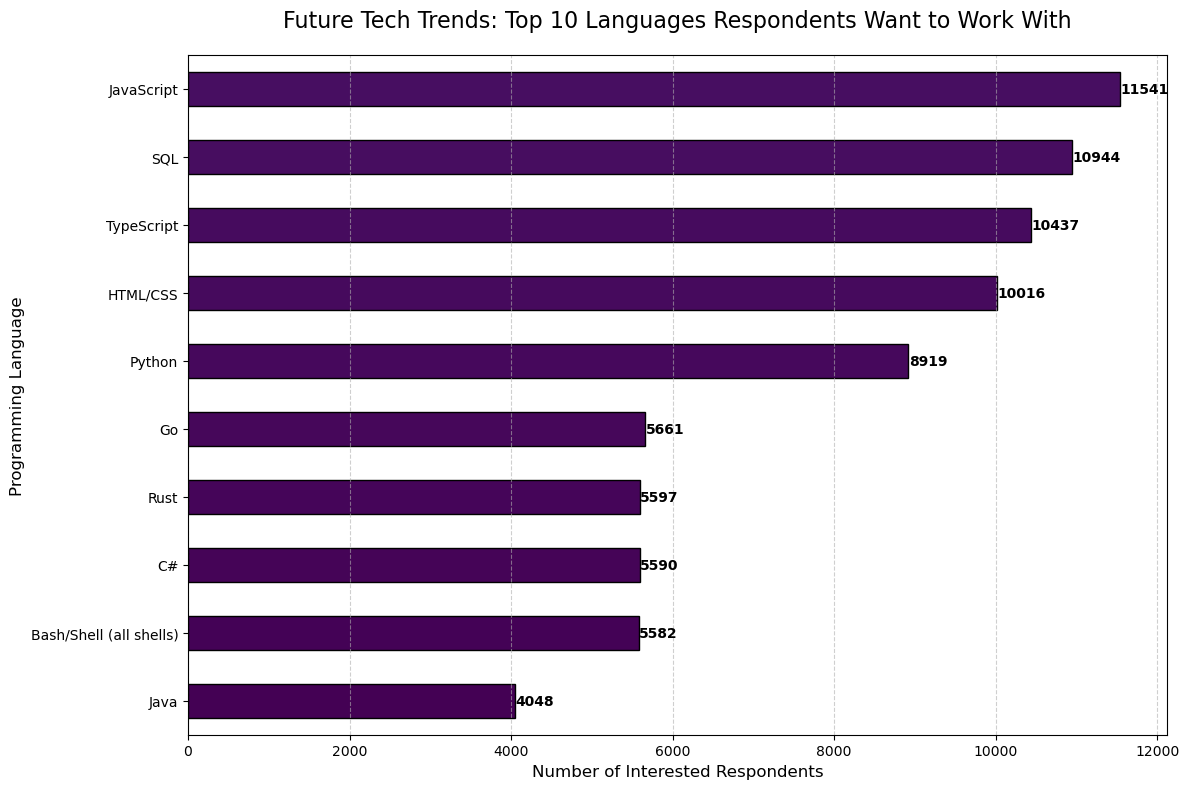

In [8]:

# 1. استخدام الاسم الصحيح للعمود من قائمتك
column_name = 'LanguageWantToWorkWith'

# 2. تجهيز البيانات وتفكيكها
# نقوم بحذف القيم المفقودة أولاً
df_future = df[[column_name]].dropna().copy()

# تفكيك اللغات (لأن الصف الواحد قد يحتوي على Python;SQL;Go)
df_future['Language'] = df_future[column_name].str.split(';')
df_exploded = df_future.explode('Language')

# 3. حساب التكرار لأعلى 10 لغات يطمح المبرمجون لتعلمها
lang_counts = df_exploded['Language'].value_counts().nlargest(10)

# 4. رسم المخطط الشريطي
plt.figure(figsize=(12, 8))

# رسم الأعمدة بشكل أفقي لسهولة قراءة أسماء اللغات
colors = plt.cm.viridis(range(len(lang_counts))) # تدرج لوني جذاب
lang_counts.sort_values(ascending=True).plot(kind='barh', color=colors, edgecolor='black')

# إضافة العناوين والتنسيقات
plt.title('Future Tech Trends: Top 10 Languages Respondents Want to Work With', fontsize=16, pad=20)
plt.xlabel('Number of Interested Respondents', fontsize=12)
plt.ylabel('Programming Language', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# إضافة الأرقام فوق كل عمود للتوضيح
for i, v in enumerate(lang_counts.sort_values(ascending=True)):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

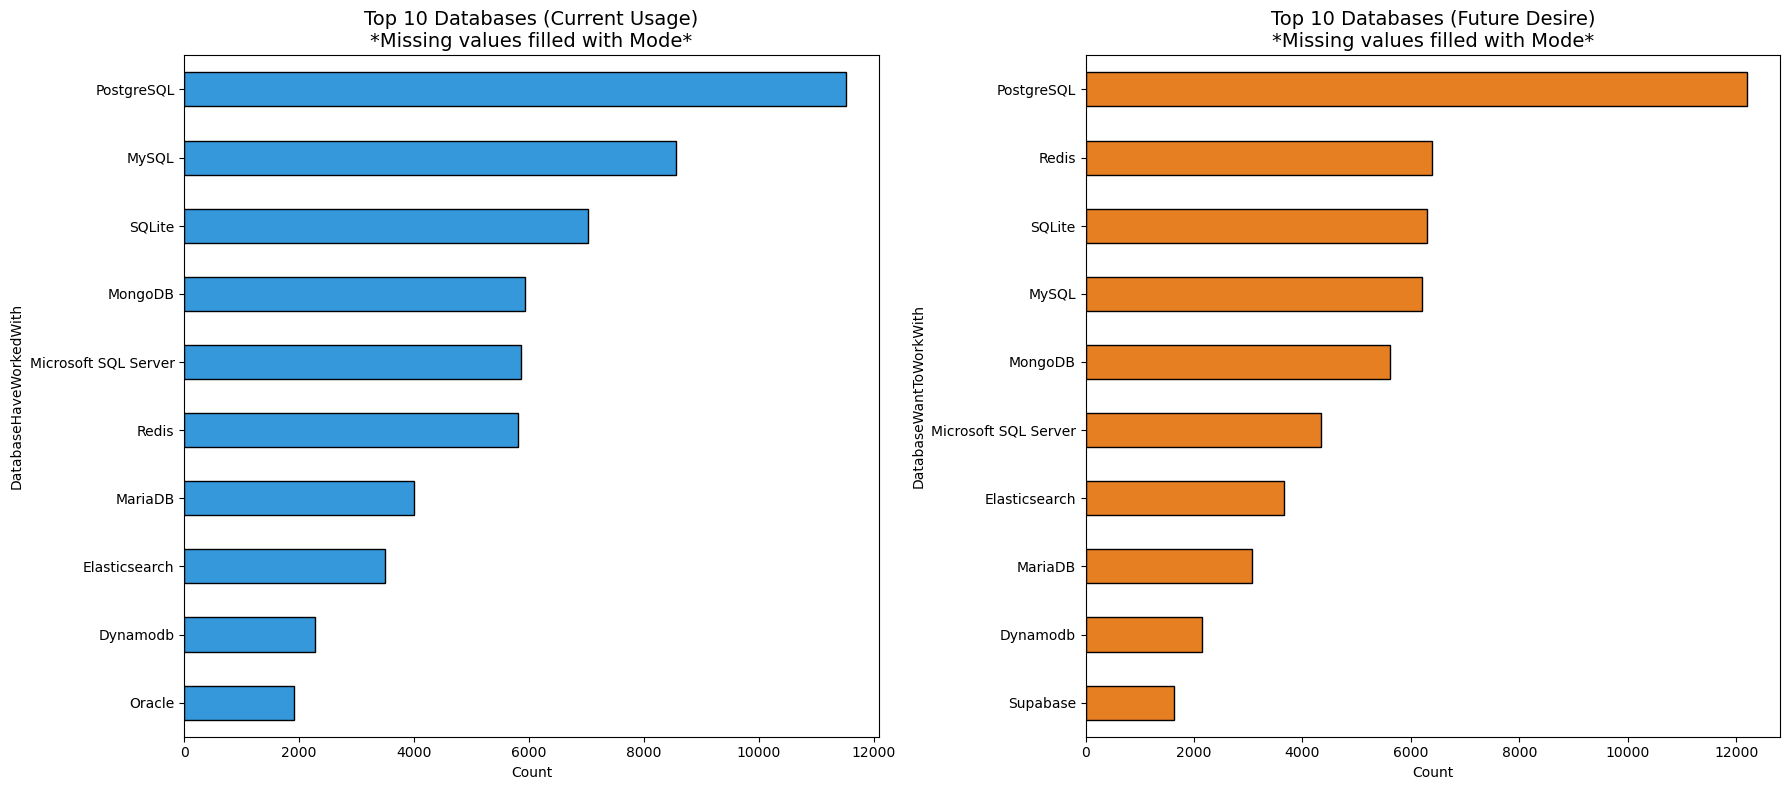

In [9]:

# 1. تحديد الأعمدة المطلوبة
cols = ['DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith']

# 2. ملء القيم الفارغة بالأكثر تكراراً (Mode) لكل عمود
for col in cols:
    most_frequent = df[col].mode()[0]  # الحصول على القيمة الأكثر تكراراً
    df[col] = df[col].fillna(most_frequent)

# 3. دالة لتحليل وتفكيك اللغات بعد ملء الفراغات
def process_data(data_frame, column_name):
    # تفكيك النصوص (Explode) لأن الخلية الواحدة تحتوي على عدة قواعد بيانات
    exploded = data_frame[column_name].str.split(';').explode()
    return exploded.value_counts().nlargest(10)

# 4. الحصول على أفضل 10 قواعد بيانات (الحالية والمستقبلية)
current_db_counts = process_data(df, 'DatabaseHaveWorkedWith')
future_db_counts = process_data(df, 'DatabaseWantToWorkWith')

# 5. الرسم البياني
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# الرسم الأول: الاستخدام الحالي
current_db_counts.sort_values().plot(kind='barh', ax=ax1, color='#3498db', edgecolor='black')
ax1.set_title('Top 10 Databases (Current Usage)\n*Missing values filled with Mode*', fontsize=14)
ax1.set_xlabel('Count')

# الرسم الثاني: الطلب المستقبلي
future_db_counts.sort_values().plot(kind='barh', ax=ax2, color='#e67e22', edgecolor='black')
ax2.set_title('Top 10 Databases (Future Desire)\n*Missing values filled with Mode*', fontsize=14)
ax2.set_xlabel('Count')

plt.tight_layout()
plt.show()

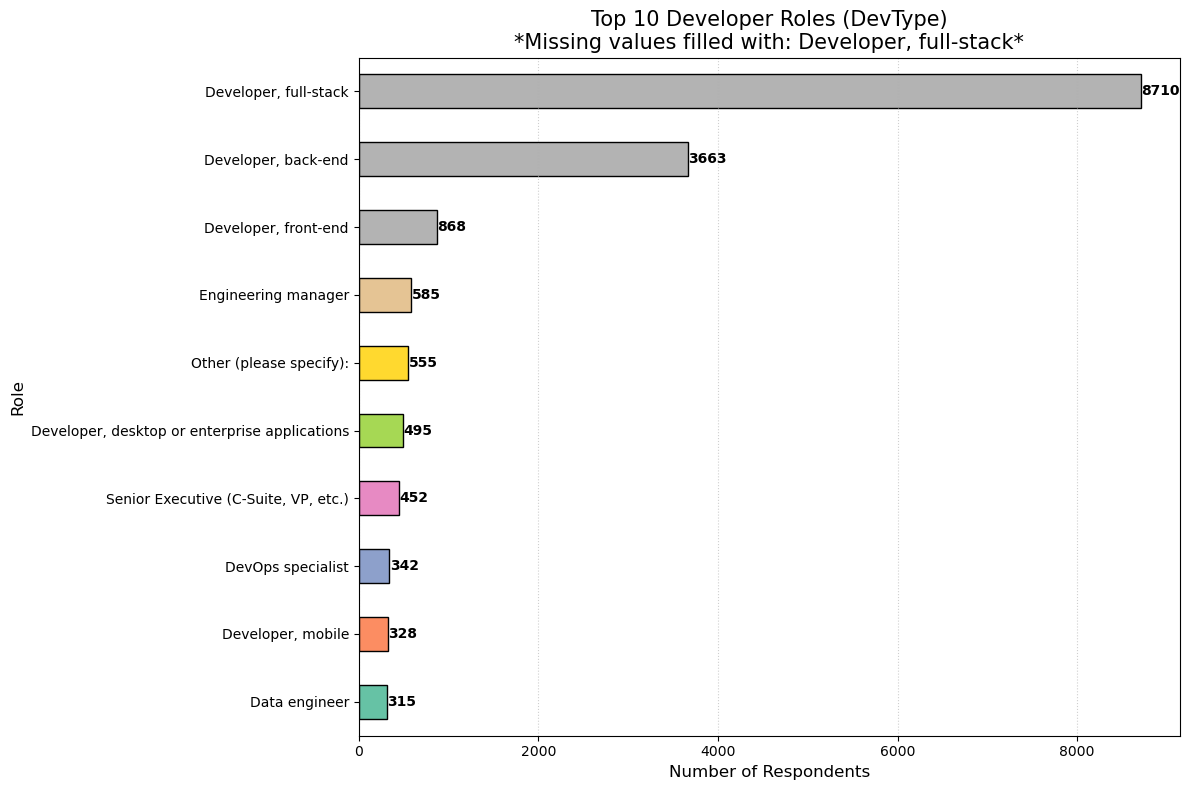


--- جدول تحليل الأدوار الوظيفية (أعلى 5) ---
                         Frequency
DevType                           
Developer, full-stack         8710
Developer, back-end           3663
Developer, front-end           868
Engineering manager            585
Other (please specify):        555


In [10]:

# 1. تحديد العمود المطلوب
column_name = 'DevType'

# 2. ملء القيم الفارغة بالقيمة الأكثر تكراراً (Mode) لضمان عدم حذف أي صف
most_frequent_role = df[column_name].mode()[0]
df_filled = df.copy()
df_filled[column_name] = df_filled[column_name].fillna(most_frequent_role)

# 3. حساب عدد الموظفين في كل دور وظيفي
# الترتيب التنازلي يتم تلقائياً بواسطة value_counts()
job_counts = df_filled[column_name].value_counts()

# 4. رسم المخطط الشريطي (أفضل 10 أدوار وظيفية)
plt.figure(figsize=(12, 8))

# رسم الأعمدة بشكل أفقي لسهولة القراءة
colors = plt.cm.Set2(range(len(job_counts.head(10))))
job_counts.head(10).sort_values(ascending=True).plot(kind='barh', color=colors, edgecolor='black')

# 5. إضافة العناوين والتفاصيل
plt.title(f'Top 10 Developer Roles (DevType)\n*Missing values filled with: {most_frequent_role}*', fontsize=15)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# إضافة الأرقام بدقة على طرف كل عمود
for i, v in enumerate(job_counts.head(10).sort_values(ascending=True)):
    plt.text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. تحليل على شكل جدول (كما طلبت لأي شيء)
print("\n--- جدول تحليل الأدوار الوظيفية (أعلى 5) ---")
print(job_counts.head(5).to_frame(name='Frequency'))

In [11]:

# 1. ملء قيم الرواتب المفقودة بالمتوسط العام (Mean)
mean_comp = df['ConvertedCompYearly'].mean()
df_salary = df.copy()
df_salary['ConvertedCompYearly'] = df_salary['ConvertedCompYearly'].fillna(mean_comp)

# 2. ملء قيم الوظائف المفقودة بالمنوال (كما فعلنا سابقاً)
most_frequent_role = df_salary['DevType'].mode()[0]
df_salary['DevType'] = df_salary['DevType'].fillna(most_frequent_role)

# 3. حساب متوسط الراتب لكل وظيفة
# نقوم بالتجميع حسب الوظيفة وحساب المتوسط ثم الترتيب تنازلياً
salary_analysis = df_salary.groupby('DevType')['ConvertedCompYearly'].mean().sort_values(ascending=False)

# 4. عرض أعلى 5 وظائف في جدول
print("--- أعلى 5 وظائف من حيث متوسط الراتب السنوي ---")
print(salary_analysis.head(5).to_frame(name='Average Annual Salary (USD)'))

--- أعلى 5 وظائف من حيث متوسط الراتب السنوي ---
                                      Average Annual Salary (USD)
DevType                                                          
Senior Executive (C-Suite, VP, etc.)                125399.419429
Hardware Engineer                                   123095.997503
Blockchain                                          115152.796653
Engineering manager                                 111074.179476
Developer Advocate                                  106275.871879


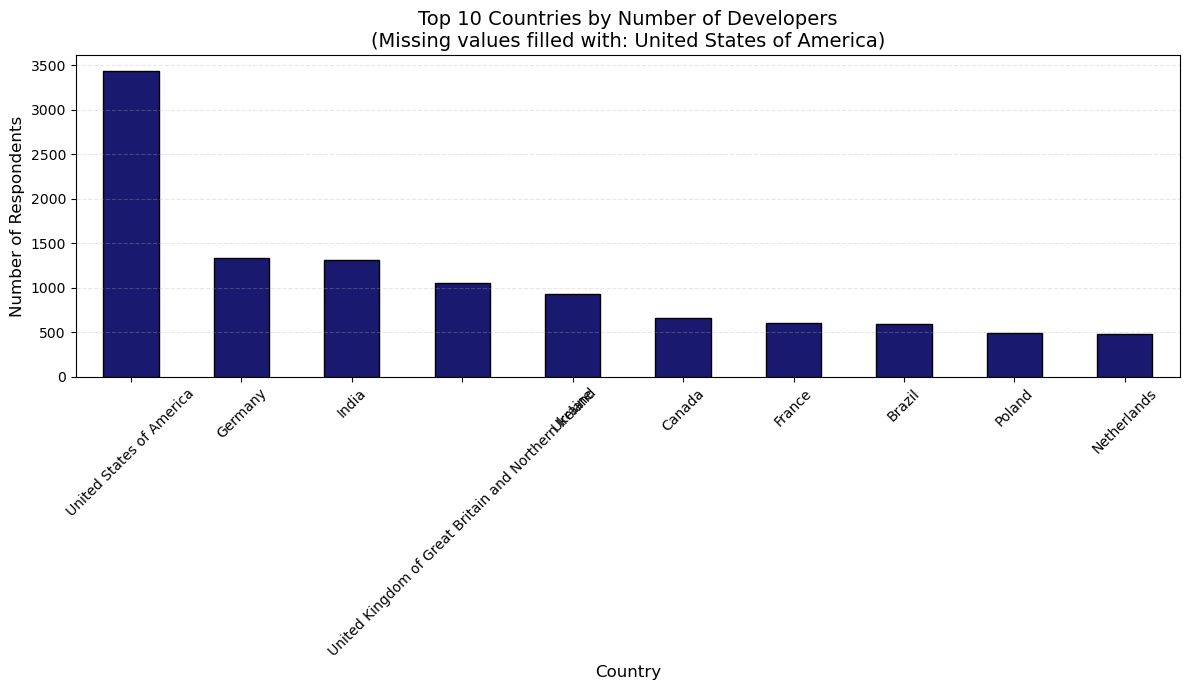

--- القائمة التفصيلية لأعلى 10 دول ---
                                                    Developer Count
Country                                                            
United States of America                                       3441
Germany                                                        1339
India                                                          1316
United Kingdom of Great Britain and Northern Ir...             1053
Ukraine                                                         931
Canada                                                          661
France                                                          598
Brazil                                                          587
Poland                                                          494
Netherlands                                                     480


In [12]:

# 1. تحديد العمود
column_name = 'Country'

# 2. ملء القيم الفارغة بالدولة الأكثر تكراراً (Mode)
most_frequent_country = df[column_name].mode()[0]
df_countries = df.copy()
df_countries[column_name] = df_countries[column_name].fillna(most_frequent_country)

# 3. حساب عدد المطورين لكل دولة (ترتيب تنازلي)
country_counts = df_countries[column_name].value_counts().nlargest(10)

# 4. رسم المخطط الشريطي
plt.figure(figsize=(12, 7))
country_counts.plot(kind='bar', color='midnightblue', edgecolor='black')

# 5. التنسيق
plt.title(f'Top 10 Countries by Number of Developers\n(Missing values filled with: {most_frequent_country})', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. عرض جدول النتائج
print("--- القائمة التفصيلية لأعلى 10 دول ---")
print(country_counts.to_frame(name='Developer Count'))

In [13]:
print("Top 10 Countries by Number of Developers")
country_counts.to_frame(name='Developer Count')

Top 10 Countries by Number of Developers


,Developer Count
Country,
United States of America,3441
Germany,1339
India,1316
United Kingdom of Great Britain and Northern Ireland,1053
Ukraine,931
Canada,661
France,598
Brazil,587
Poland,494
